# Time-Series Forecasting with ARIMA / SARIMA

## Project Overview

This project develops an end-to-end time-series forecasting pipeline for analyzing historical demand patterns and generating future demand predictions.

The analysis covers:

- Historical demand trends
- Time-series decomposition
- Seasonality analysis
- Stationarity testing using the Augmented Dickey-Fuller (ADF) test
- Differencing
- ARIMA / SARIMA model selection
- Forecast evaluation using MAPE and RMSE
- 30-day future demand forecasting

### Dataset

The dataset contains daily demand observations along with marketing-event and holiday indicators.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Dataset

In [3]:
DATA_PATH = "../data/daily-demand-series.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


## 2. Initial Data Inspection

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (30, 4)

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   date             30 non-null     str  
 1   demand           30 non-null     int64
 2   marketing_event  30 non-null     int64
 3   holiday          30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB
None

Missing Values:
date               0
demand             0
marketing_event    0
holiday            0
dtype: int64

Duplicate Rows: 0


In [5]:
df.describe()

,demand,marketing_event,holiday
count,30.000000,30.000000,30.000000
mean,142.100000,0.266667,0.133333
std,13.839848,0.449776,0.345746
min,118.000000,0.000000,0.000000
25%,132.500000,0.000000,0.000000
50%,142.000000,0.000000,0.000000
75%,150.250000,0.750000,0.000000
max,174.000000,1.000000,1.000000


## 3. DateTime Preprocessing

In [6]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df = df.set_index("date")

df.head()

,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


In [7]:
print("Start Date:", df.index.min())
print("End Date:", df.index.max())
print("Frequency:", pd.infer_freq(df.index))

Start Date: 2026-06-01 00:00:00
End Date: 2026-06-30 00:00:00
Frequency: D


In [8]:
df[["demand", "marketing_event", "holiday"]].head(10)

,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0
2026-06-06,151,1,0
2026-06-07,143,0,1
2026-06-08,126,0,0
2026-06-09,129,0,0


In [9]:
print(df.index.is_monotonic_increasing)

True


## 4. Historical Demand Trend

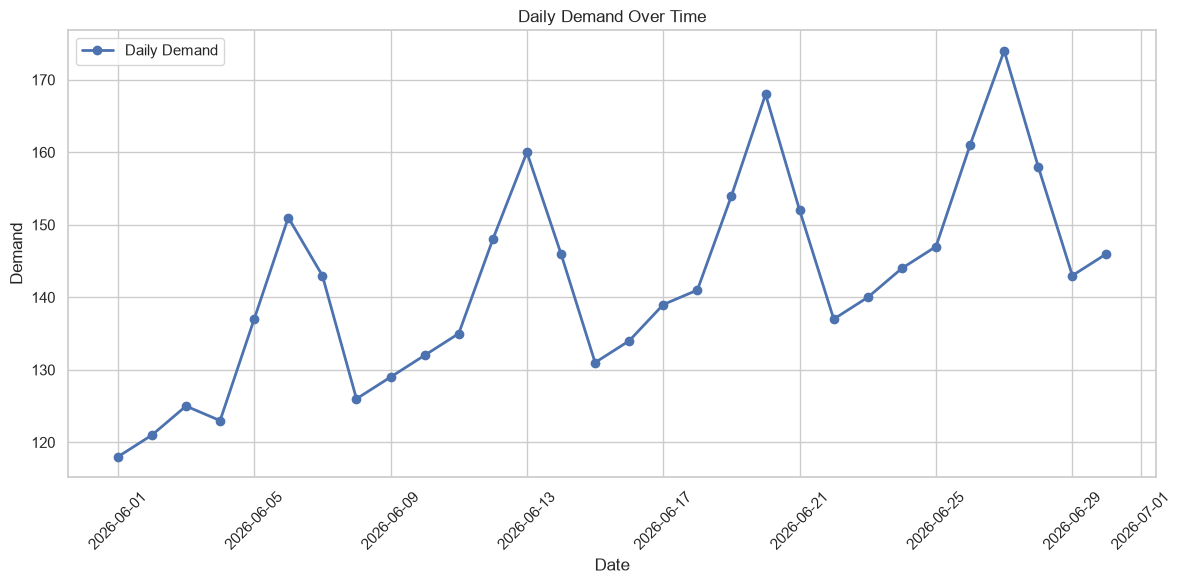

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["demand"],
    marker="o",
    linewidth=2,
    label="Daily Demand"
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()